# Metal-superconductor transport

At a normal-metal/superconductor (N-S) interface, sub-gap transport proceeds via Andreev
reflection: an incoming electron is reflected as a hole, transferring a Cooper pair into the
superconductor. `heterostructures.build(h1,h2)` with `h2` carrying an s-wave pairing amplitude
automatically dispatches `.didv` to the BdG scattering-matrix formula. Sweeping the interface
transparency $T$ interpolates between two regimes: at $T=1$ (perfect transparency, no
tunnel barrier), Andreev reflection doubles the zero-bias conductance to $2e^2/h$ per channel
relative to the normal-state value; at small $T$ (the tunneling limit), conductance is instead
peaked at the gap edge $E=\pm\Delta$ and suppressed at zero bias. This is the BTK crossover.

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import heterostructures

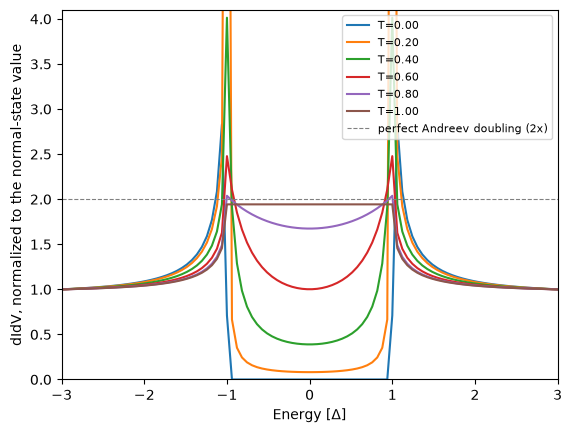

In [2]:
g = geometry.chain()
h = g.get_hamiltonian()
h1 = h.copy() # normal lead
h2 = h.copy() # superconducting lead
delta = 0.01 # superconducting gap
h2.add_swave(delta)
es = np.linspace(-.03,.03,100)
for T in np.linspace(1e-3,1.0,6): # loop over interface transparencies
    HT = heterostructures.build(h1,h2)
    HT.set_coupling(T)
    Gs = np.array([HT.didv(energy=e) for e in es])
    plt.plot(es/delta,Gs/Gs[0],label=f"T={T:.2f}")

plt.axhline(2.0,c="grey",ls="--",lw=0.8,label="perfect Andreev doubling (2x)")
plt.ylim([0,4.1]) ; plt.xlim([-3,3])
plt.xlabel(r"Energy [$\Delta$]") ; plt.ylabel("dIdV, normalized to the normal-state value")
plt.legend(fontsize=8)
plt.show()

The same crossover as a map, with the normalized conductance as a function of the energy and of the transparency $T$.

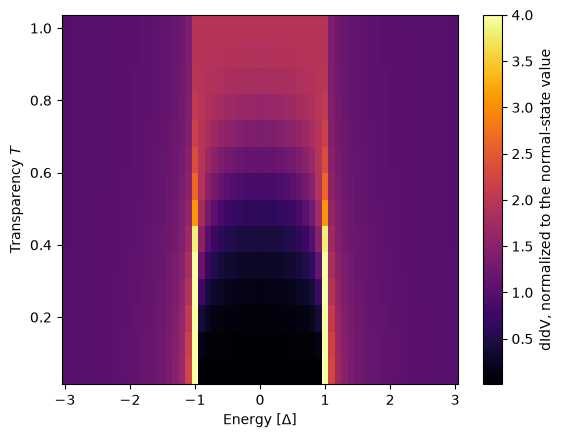

In [3]:
Ts = np.linspace(0.05,1.0,14) # interface transparencies
es_map = np.linspace(-.03,.03,61)
Gmap = []
for T in Ts:
    HT = heterostructures.build(h1,h2)
    HT.set_coupling(T)
    Gs = np.array([HT.didv(energy=e) for e in es_map])
    Gmap.append(Gs/Gs[0]) # normalized to the normal-state value

plt.pcolormesh(es_map/delta,Ts,np.array(Gmap),shading="auto",cmap="inferno",vmax=4)
plt.colorbar(label="dIdV, normalized to the normal-state value")
plt.xlabel(r"Energy [$\Delta$]") ; plt.ylabel("Transparency $T$")
plt.show()